In [27]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

In [48]:
RUN_ID = 'new'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1e3)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.1
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

In [29]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)
display(data)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.009707,1785.063477,0.007000,0.032111,0.000000,0.000042
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.009707,1785.366211,0.007000,0.032111,0.000042,0.000042
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.009707,1785.670776,0.007000,0.032111,0.000084,0.000042
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.009707,1785.975342,0.007000,0.032112,0.000127,0.000042
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.009707,1786.280151,0.007000,0.032112,0.000169,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...
209564,124,5.00,0.0,24.891078,0.000000,0.233333,0.192620,4690.878418,0.009318,0.023301,0.291108,0.000541
209565,124,5.00,0.0,24.891078,0.000000,0.231944,0.192629,4627.829590,0.009670,0.023302,0.291649,0.000541
209566,124,5.00,0.0,24.891078,0.000000,0.230556,0.192637,4564.943359,0.010054,0.023303,0.292190,0.000541
209567,124,5.00,0.0,24.891078,0.000000,0.229167,0.192645,4502.242188,0.010466,0.023304,0.292731,0.000541


In [30]:
# import scipy.integrate as integrate
# from scipy.interpolate import interp1d

# def u_par_to_d(u_par):
#     d = L * u_par /100
#     return d

# def ds_dt(y,t,i,d,sNN_model = BAT_MODEL):
#     I_interp = interp1d(t, i, fill_value="extrapolate")
#     i = I_interp(t)
#     s, soc = y
#     soc_dot = -i / Q0
#     s_dot = sNN_model.ds_net(s,i, soc,d).detach().numpy()
#     y_dot = [s_dot, soc_dot]
#     return y_dot

# sol = 

# Importing data

In [31]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


KeyError: 's'

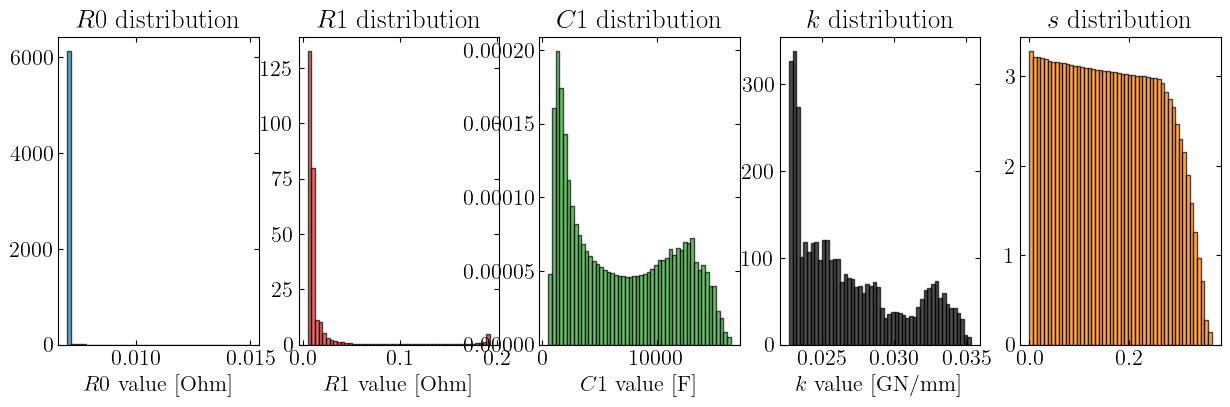

In [46]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [33]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['s'].values  / REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [34]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 4th data point for symbolic regression, total points: 48455
Using every 1th data point for symbolic regression, total points: 15749


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.0039349706
Equation: 0.7074862

Model 1: Complexity=5, Loss=0.003154274
Equation: (0.008633128 / x2) - -0.68191594

Model 2: Complexity=7, Loss=0.002928269
Equation: square(-0.020899367 / x2) + 0.6987516

Model 3: Complexity=9, Loss=0.0017672752
Equation: (cube(x0 / x2) * 3.3751636e-5) + 0.69210225

Model 4: Complexity=11, Loss=0.0004930009
Equation: cube(cube(x0 * (0.043650407 / x2))) + 0.6990086

Model 5: Complexity=13, Loss=0.00046862283
Equation: (square(cube((x0 / x2) + -7.23902)) * 6.819464e-8) + 0.69788605

Model 6: Complexity=15, Loss=0.0004586465
Equation: (square(cube(((x0 + -0.013108085) / x2) + -7.403915)) * 8.002087e-8) + 0.6978673

Model 7: Complexity=17, Loss=0.00032256148
Equation: cube(tanh(square(cube(x0 / x2)) * 1.30316e-8)) + 0.69958645

Model 8: Complexity=19, Loss=0.00026905062
Equation: (tanh(cube(cube(square(x0 / x2) * 0.0022766567))) * 0.7378943) + 0.7004337

Model 9: Complexity=21, Loss=0.00022040727
Equation: (tanh(cube(cube(squa

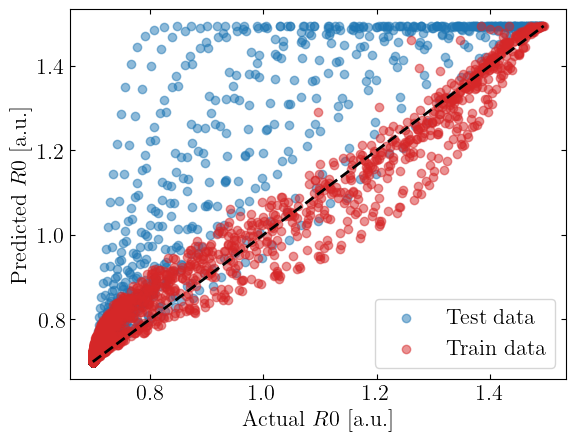

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: tanh((6.97779432715225e-8*(x0/x2 + x2*7.067745 - 6.417118)**6)**x0)*0.79400766 + 0.69958645
Loss: 9.512019e-05
Best model complexity: 27


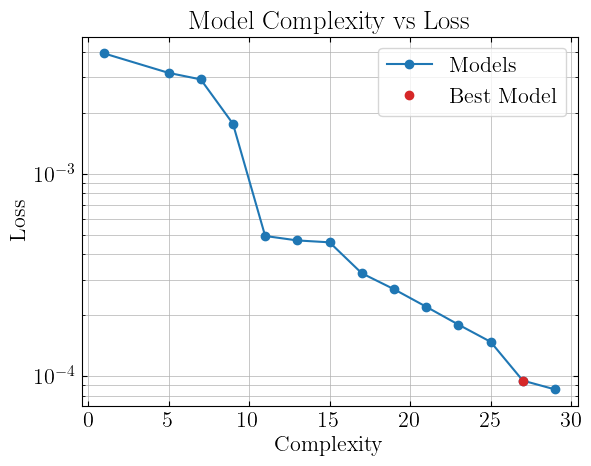

In [35]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=10.8001585
Equation: 1.7116768

Model 1: Complexity=3, Loss=6.288519
Equation: 0.61811805 / x2

Model 2: Complexity=5, Loss=4.6024075
Equation: (x0 / x2) * 0.49435648

Model 3: Complexity=7, Loss=1.4689462
Equation: cube(x0 * (0.13414285 / x2))

Model 4: Complexity=9, Loss=1.0682647
Equation: cube((x0 * 0.13137633) / x2) + 0.66689944

Model 5: Complexity=11, Loss=0.98726624
Equation: square(-1.0878966 - ((x0 / x2) * -0.26710254)) + 0.4602759

Model 6: Complexity=12, Loss=0.8137014
Equation: exp((x2 / (x0 / -47.840195)) + 5.295972) + 0.7955361

Model 7: Complexity=13, Loss=0.5226795
Equation: 4.780282 / (cube(((x0 / x2) * -0.115661755) - -2.3781135) - -0.24743326)

Model 8: Complexity=15, Loss=0.44674858
Equation: (5.6001472 / (cube((x0 * (-0.13773832 / x2)) - -2.7728076) - -0.29839328)) - -0.37236744

Model 9: Complexity=17, Loss=0.36371255
Equation: (5.0455837 / (square(square(-2.9210804 - (-0.14488854 * (x0 / x2)))) - -0.27494112)) - -0.70177543

Model 10:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x2 + (10.329191 - 0.21729645/x2)*tanh(x2/((x0/(-131.80966))) + 8.532362) - 1*(-9.869625) + 0.133561/x2
Loss: 0.15083544
Best model complexity: 25


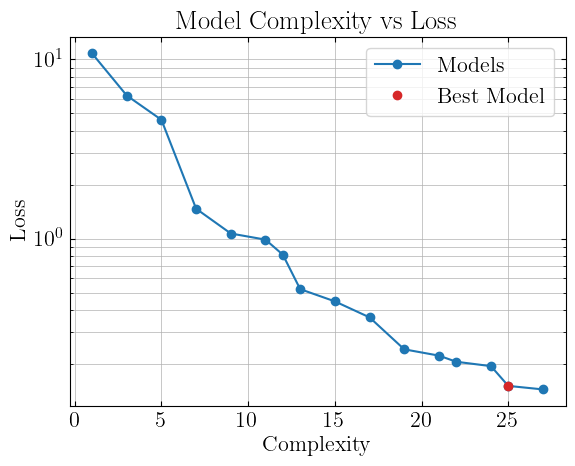

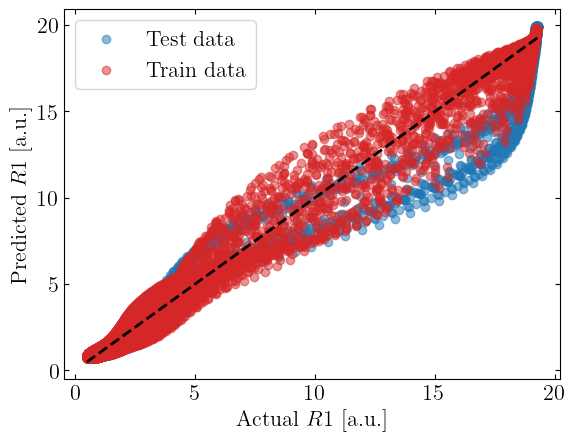

In [36]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=21.86521
Equation: 6.859815

Model 1: Complexity=3, Loss=20.794752
Equation: 7.3981223 - x2

Model 2: Complexity=5, Loss=17.340061
Equation: 11.10319 - (x2 * 7.900473)

Model 3: Complexity=7, Loss=6.609435
Equation: x2 * ((x2 * -51.548492) + 47.335148)

Model 4: Complexity=9, Loss=2.6119034
Equation: square((16.40495 - (x2 * 18.62912)) * x2)

Model 5: Complexity=10, Loss=1.7815812
Equation: exp(x2 * (12.533213 - (x2 * 14.942929)))

Model 6: Complexity=12, Loss=1.4503685
Equation: exp(x2 * (12.678501 - (x2 * 15.479891))) + x2

Model 7: Complexity=13, Loss=1.1421075
Equation: cube((x2 * 11.560833) / cosh(x2 / 0.31341287))

Model 8: Complexity=15, Loss=1.1239893
Equation: cube(x2 * ((11.557576 / cosh(x2 / 0.32295597)) + -0.17871255))

Model 9: Complexity=17, Loss=1.0246037
Equation: cube(((-0.13209121 / x0) + (11.600019 / cosh(x2 / -0.31833977))) * x2)

Model 10: Complexity=19, Loss=0.9629296
Equation: cube(x2 * ((-0.051864628 / cube(x0)) + (11.5700445 / cosh(x

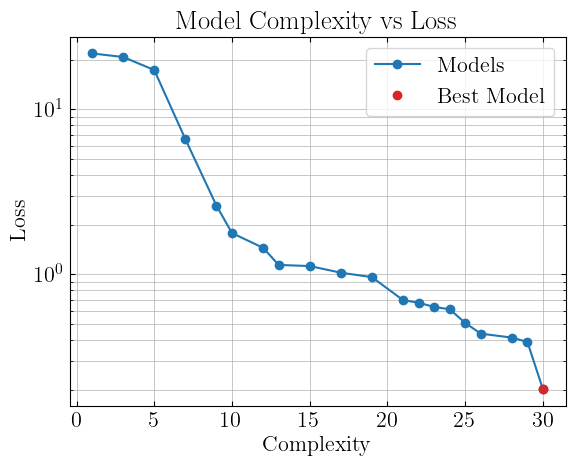

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (-0.0025677555*x1 + x2*19.152248/((x0 - x2)/cosh(x0) - (exp(x2/0.3297775) + 1.0093223)))**4
Loss: 0.20091818
Best model complexity: 30


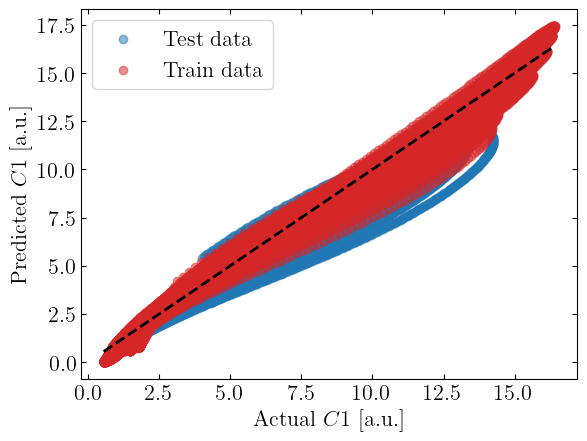

In [37]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.13329796
Equation: 2.688197

Model 1: Complexity=5, Loss=0.0031956674
Equation: (x1 * 0.037280962) + 2.250747

Model 2: Complexity=7, Loss=0.0010641061
Equation: (1.026191 ^ x1) + 1.28968

Model 3: Complexity=8, Loss=0.0010640599
Equation: exp(x1 * 0.025908096) + 1.2886919

Model 4: Complexity=9, Loss=0.0009848111
Equation: ((1.031387 ^ x1) / 1.2892258) + 1.5210199

Model 5: Complexity=10, Loss=0.00053966494
Equation: 1.3047136 + exp(0.026095029 * (x1 - x2))

Model 6: Complexity=11, Loss=0.00015789684
Equation: (1.0260661 ^ x1) + (1.3556062 - (x2 * 0.11754723))

Model 7: Complexity=12, Loss=9.702753e-05
Equation: exp((x1 - (x2 / 0.31865954)) * 0.026609879) + 1.3373516

Model 8: Complexity=14, Loss=4.4343236e-05
Equation: exp((((x2 * 2.972337) - x1) * -0.030919347) - 0.2149262) + 1.5324242

Model 9: Complexity=16, Loss=3.7770173e-05
Equation: sqrt(exp(((x2 * 2.9468856) - (x1 + -7.551717)) * -0.06307291)) + 1.5492676

Model 10: Complexity=18, Loss=1.9173078e

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(exp(0.05419318*x1 - 0.15088513949462*x2 + 0.0700355289888888*exp(x1*(-0.2564476*x2 - 0.087245661018028)))) + 1.3089749
Loss: 8.496308e-06
Best model complexity: 27


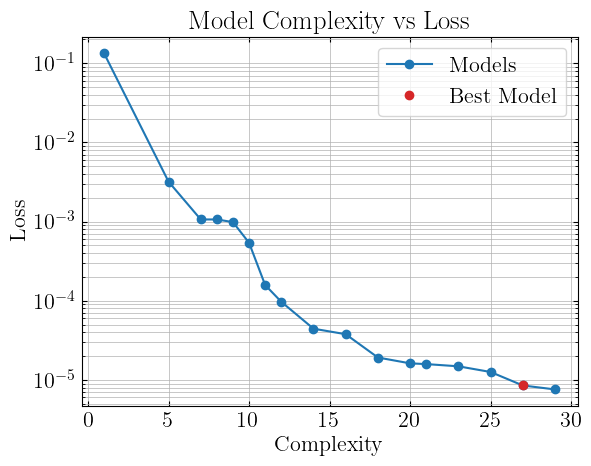

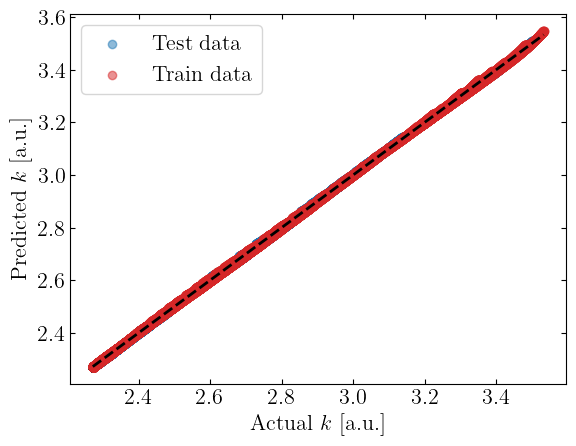

In [38]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.9376888
Equation: 1.633056

Model 1: Complexity=3, Loss=0.4925383
Equation: 2.1683416 - x2

Model 2: Complexity=5, Loss=0.010208651
Equation: 3.5596085 - (x2 * 3.5894868)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 3.5596085 - 3.5894868*x2
Loss: 0.010208651
Best model complexity: 5


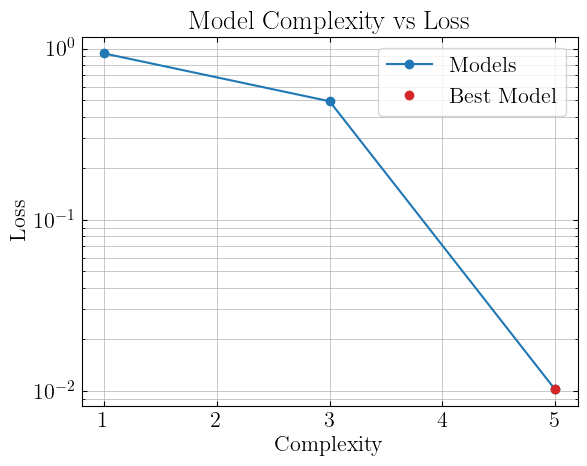

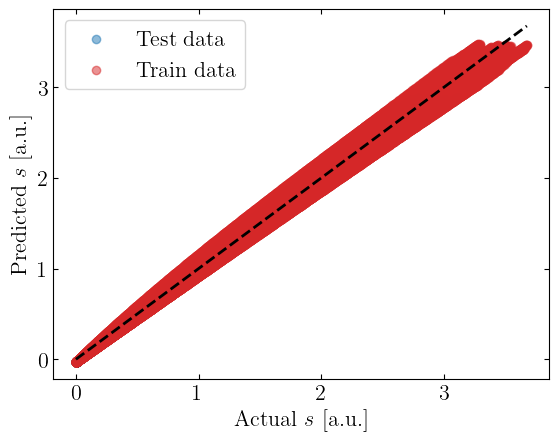

In [39]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(X_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = 10, selection = SELECTION)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

In [40]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [41]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

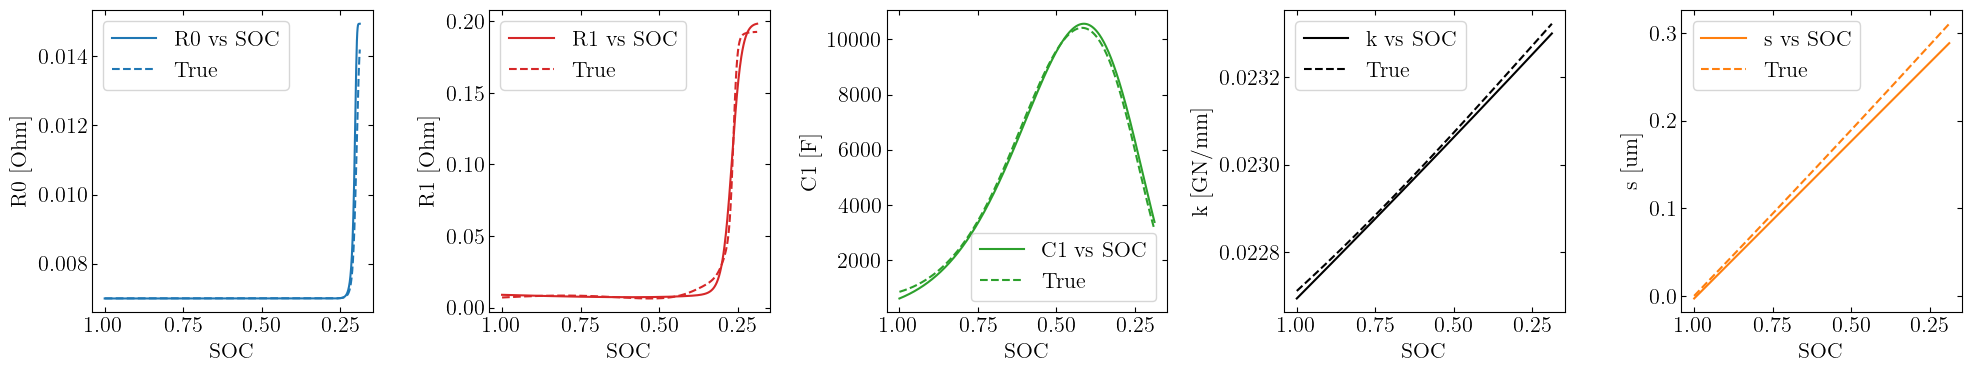

In [42]:
def plot_soc(models, traj):
    C_fixed = traj['C']
    u_per_fixed = traj['u_per']
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        Y_true = traj[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()



traj = get_traj(trajectory_id = 1, test = True)
plot_soc(MODEL_DICT, traj)

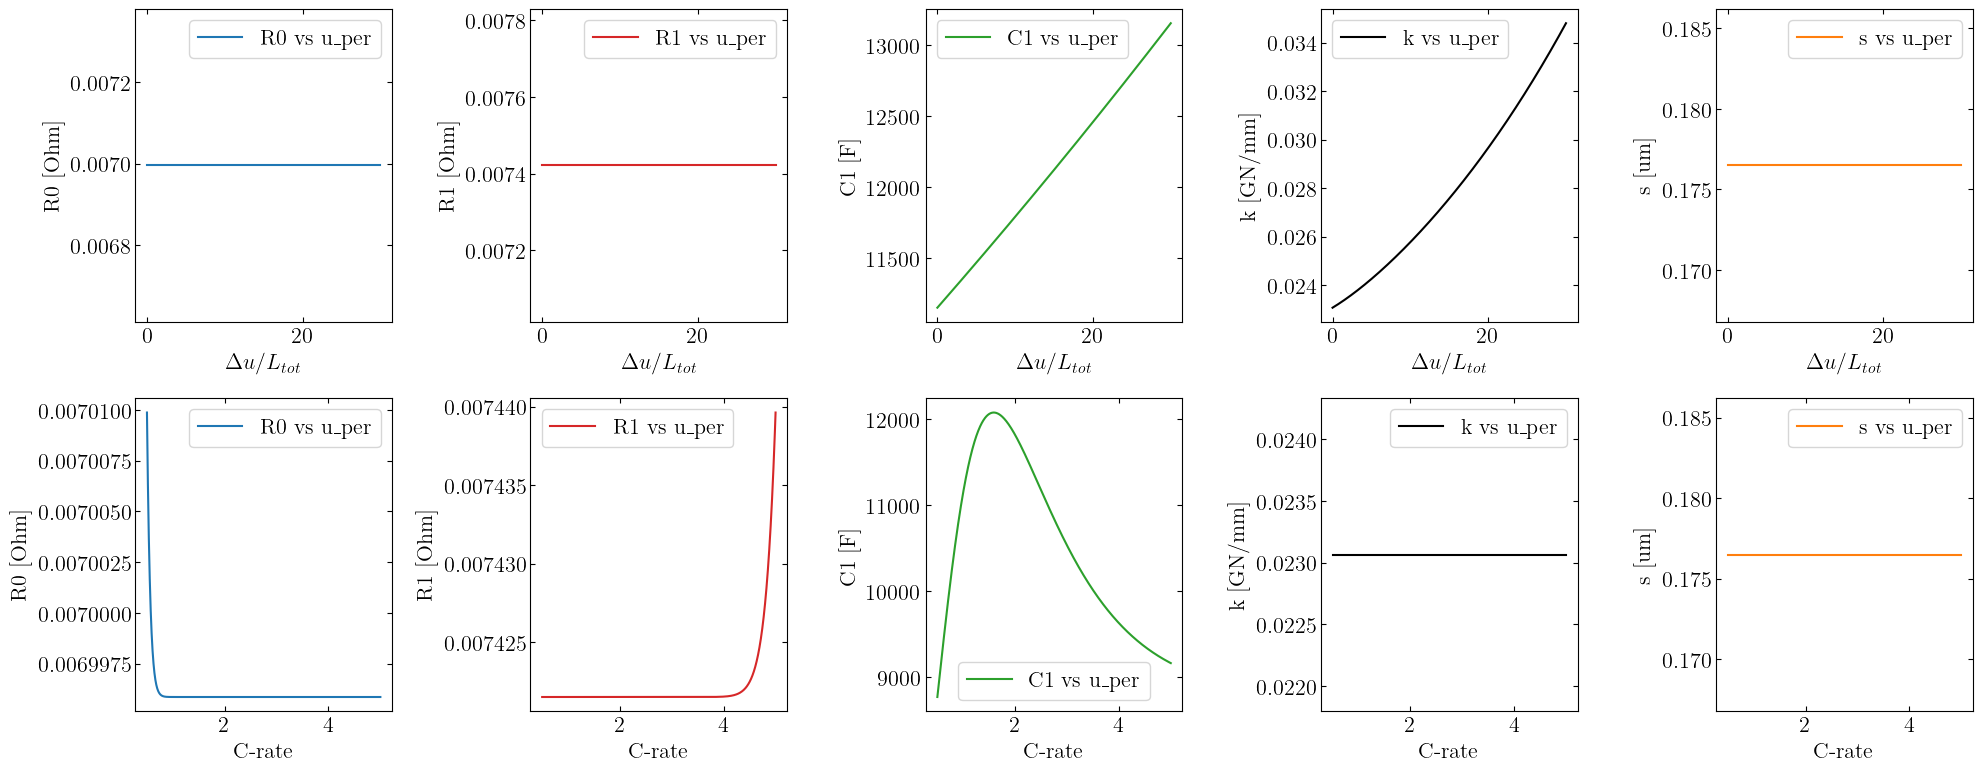

In [43]:
def plot_d(models):
    u_per = np.linspace(0,30,1000)
    C_fixed = 1
    C = np.linspace(0.5,5,1000)
    u_fixed = 0
    soc_fixed = 0.5
    X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
    X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
    f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
    for var in VARIABLES:
        model = models[var]
        Y_plot = model.predict(X_plot1) * REF_VALUES[var]
        ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
        ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
        ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[0,VARIABLES.index(var)].legend()
        Y_plot = model.predict(X_plot2) * REF_VALUES[var]
        ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
        ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
        ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[1,VARIABLES.index(var)].legend()
        
    plt.tight_layout()

plot_d(MODEL_DICT)


In [49]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')